# 加利福尼亚房价

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch

# 加载加利福尼亚房价数据
california = fetch_california_housing(data_home = './data')
X = california.data          # 特征
y = california.target        # 房价

# 对特征进行归一化（标准化处理：均值为0，方差为1）
scaler = StandardScaler()
X = scaler.fit_transform(X)


# 封装为自定义的Dataset
class CaliforniaHousingDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1) # 变成列向量

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# 划分训练集、验证集和测试集
from sklearn.model_selection import train_test_split

# 先划分出测试集（20%），剩下的用于训练和验证
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 再从剩下的80%数据中划分出验证集（20%），即最终验证集占全体16%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# 分别构造训练集、验证集和测试集的Dataset
train_dataset = CaliforniaHousingDataset(X_train, y_train)
val_dataset = CaliforniaHousingDataset(X_val, y_val)
test_dataset = CaliforniaHousingDataset(X_test, y_test)

# 构造DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [2]:
train_dataset[0]

(tensor([ 0.4402, -0.1303,  0.4423,  0.0414, -0.4879,  0.0301,  1.1087, -0.6989]),
 tensor([1.7690]))

In [3]:
import torch.nn as nn

# 搭建回归模型，隐藏层30个神经元，输出层一个
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)

# 实例化模型
input_dim = X.shape[1]
model = RegressionModel(input_dim)

In [4]:
# 输出每层参数
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:5]}")

# 做一次前向计算
sample_X = torch.tensor(X_train[:1], dtype=torch.float32).unsqueeze(0)
output = model(sample_X)
print("前向计算输出: ", output)

Layer: net.0.weight | Size: torch.Size([30, 8]) | Values : tensor([[ 0.1082, -0.3432,  0.1296, -0.1009,  0.0702, -0.2681,  0.0568, -0.0753],
        [-0.1396, -0.2802,  0.2297, -0.0033, -0.1325,  0.3064,  0.3193, -0.0084],
        [ 0.2163, -0.2677,  0.0661,  0.3391,  0.1378,  0.0727,  0.3278, -0.1568],
        [-0.0922, -0.1155, -0.0963,  0.3229, -0.0198,  0.3526, -0.3258,  0.1317],
        [ 0.0289, -0.0849, -0.3306, -0.2403,  0.0634,  0.2318, -0.3070, -0.2555]],
       grad_fn=<SliceBackward0>)
Layer: net.0.bias | Size: torch.Size([30]) | Values : tensor([-0.0798,  0.1636,  0.2428, -0.1168, -0.1574], grad_fn=<SliceBackward0>)
Layer: net.2.weight | Size: torch.Size([1, 30]) | Values : tensor([[ 0.1326, -0.0693, -0.1355,  0.0006,  0.0524,  0.0206, -0.0691,  0.0170,
          0.0275, -0.1152,  0.1312,  0.1557, -0.0210,  0.1504,  0.1804, -0.1219,
         -0.1676, -0.1643,  0.0607,  0.1372, -0.1429, -0.0876,  0.0717, -0.0982,
          0.0027,  0.1804,  0.0711,  0.0970, -0.1670, -0.0507

Epoch [1/30], Train Loss: 1.2432, Val Loss: 0.6645
Best regression model saved at epoch 1.
Epoch [2/30], Train Loss: 0.5278, Val Loss: 0.5414
Best regression model saved at epoch 2.
Epoch [3/30], Train Loss: 0.4685, Val Loss: 0.4896
Best regression model saved at epoch 3.
Epoch [4/30], Train Loss: 0.4431, Val Loss: 0.4648
Best regression model saved at epoch 4.
Epoch [5/30], Train Loss: 0.4313, Val Loss: 0.4542
Best regression model saved at epoch 5.
Epoch [6/30], Train Loss: 0.4220, Val Loss: 0.4453
Best regression model saved at epoch 6.
Epoch [7/30], Train Loss: 0.4104, Val Loss: 0.4328
Best regression model saved at epoch 7.
Epoch [8/30], Train Loss: 0.4027, Val Loss: 0.4281
Best regression model saved at epoch 8.
Epoch [9/30], Train Loss: 0.3942, Val Loss: 0.4183
Best regression model saved at epoch 9.
Epoch [10/30], Train Loss: 0.3884, Val Loss: 0.4154
Best regression model saved at epoch 10.
Epoch [11/30], Train Loss: 0.3893, Val Loss: 0.4135
Best regression model saved at epoch

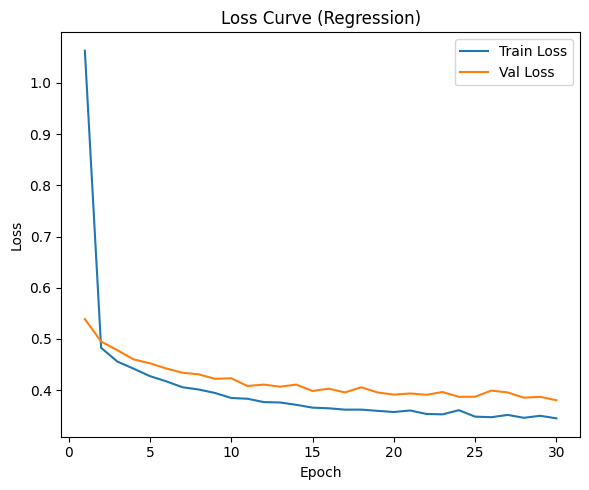

In [17]:
import torch.optim as optim
import torch.nn as nn
from copy import deepcopy
from model_train import Trainer
from importlib import reload
import model_train
reload(model_train)
from model_train import Trainer

# 学习率列表
lr_list = [1e-2, 3e-2, 3e-1, 1e-3]
best_val_loss = float('inf')
best_lr = None
best_model_state = None
trainers = {}
metrics = {}

for lr in lr_list:
    # 为每个学习率重建模型（避免权重污染）
    model = RegressionModel(input_dim)
    
    # 指定优化器
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 初始化Trainer，传入optimizer参数
    trainer = Trainer(
        model,
        train_dataloader,
        val_dataloader,
        optimizer,  # 明确指定优化器
        early_stop=True,
        early_stop_mode='val_loss',
        patience=10,
        save_path=f'best_regression_model_lr.pth'
    )
    trainer.criterion = nn.MSELoss()
    trainer.train_regression(epochs=30)
    
    # 解决没有history的问题：手动构造history属性
    # 格式与原代码需求保持一致
    if not hasattr(trainer, 'history'):
        trainer.history = {}
    # 记录val_loss、train_loss等。如果Trainer有收集这类list，可以直接用
    # 若Trainer有 val_losses、train_losses，则保存
    trainer.history['val_loss'] = getattr(trainer, 'val_losses', [])
    trainer.history['train_loss'] = getattr(trainer, 'train_losses', [])
    
    val_loss = trainer.history.get('val_loss', [float('inf')])[-1] if trainer.history.get('val_loss') else float('inf')
    trainers[lr] = trainer
    metrics[lr] = trainer.history

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lr = lr
        best_model_state = deepcopy(model.state_dict())

print(f"Best lr: {best_lr}, Best val_loss: {best_val_loss}")

# 若需要画最优学习率下的训练过程损失曲线
best_trainer = trainers[best_lr]
best_trainer.plot_metrics(acc=False)

In [9]:
# 评估
trainer.evaluating(val_dataloader)

(0.0, 0.35586582926603466)